In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [2]:
# Cell 2 — Version 1: Iris dataset — RF vs single tree
iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

single = DecisionTreeClassifier(max_depth=4, random_state=42)
single.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, max_depth=4,
                             oob_score=True, random_state=42)
rf.fit(X_train, y_train)

print(f"Single Tree  — Test Accuracy: {accuracy_score(y_test, single.predict(X_test))*100:.1f}%")
print(f"Random Forest — Test Accuracy: {accuracy_score(y_test, rf.predict(X_test))*100:.1f}%")
print(f"Random Forest — OOB  Accuracy: {rf.oob_score_*100:.1f}%")
print()
print(classification_report(y_test, rf.predict(X_test), target_names=iris.target_names))

Single Tree  — Test Accuracy: 100.0%
Random Forest — Test Accuracy: 100.0%
Random Forest — OOB  Accuracy: 92.5%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



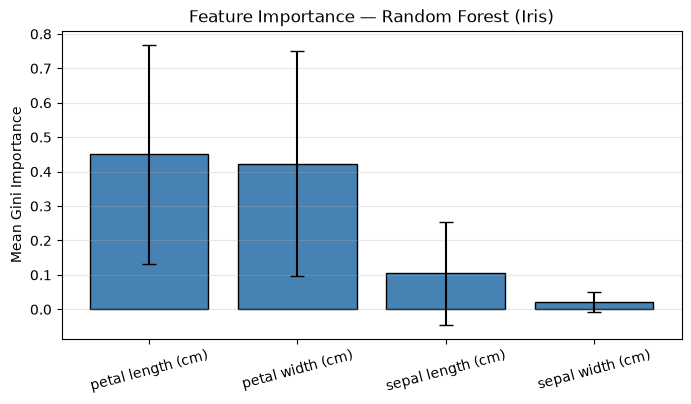

petal length (cm)             : 0.4501 ± 0.3190
petal width (cm)              : 0.4236 ± 0.3261
sepal length (cm)             : 0.1051 ± 0.1494
sepal width (cm)              : 0.0212 ± 0.0283


In [3]:
# Cell 3 — Version 2: feature importance bar chart
importances = rf.feature_importances_
features    = iris.feature_names
std         = np.std([t.feature_importances_ for t in rf.estimators_], axis=0)
sorted_idx  = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 4))
plt.bar(range(len(features)), importances[sorted_idx],
        yerr=std[sorted_idx], color='steelblue',
        edgecolor='black', capsize=5)
plt.xticks(range(len(features)), [features[i] for i in sorted_idx], rotation=15)
plt.ylabel('Mean Gini Importance')
plt.title('Feature Importance — Random Forest (Iris)')
plt.grid(True, alpha=0.3, axis='y'); plt.show()

for i in sorted_idx:
    print(f"{features[i]:30s}: {importances[i]:.4f} ± {std[i]:.4f}")

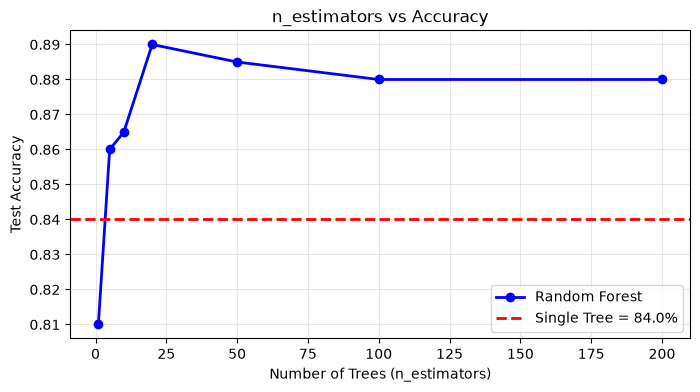

In [4]:
# Cell 4 — Version 3: n_estimators vs accuracy curve
np.random.seed(42)
X, y = make_classification(n_samples=1000, n_features=10, n_redundant=2,
                            random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

tree_counts = [1, 5, 10, 20, 50, 100, 200]
accs        = []

for n in tree_counts:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    accs.append(accuracy_score(y_test, rf.predict(X_test)))

single_acc = accuracy_score(y_test,
    DecisionTreeClassifier(random_state=42).fit(X_train, y_train).predict(X_test))

plt.figure(figsize=(8, 4))
plt.plot(tree_counts, accs, 'b-o', linewidth=2, label='Random Forest')
plt.axhline(single_acc, color='red', linestyle='--', linewidth=2,
            label=f'Single Tree = {single_acc*100:.1f}%')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Test Accuracy')
plt.title('n_estimators vs Accuracy')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

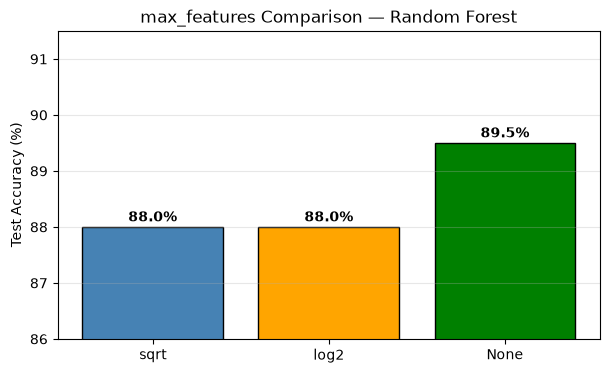

max_features=sqrt  → 88.0%
max_features=log2  → 88.0%
max_features=None  → 89.5%


In [5]:
# Cell 5 — Version 4: max_features comparison
# max_features controls how many features checked per split
# 'sqrt' = default (good for classification)
# 'log2' = fewer features = more randomness
# None   = all features = closer to bagging, less random

results = {}
for mf in ['sqrt', 'log2', None]:
    rf = RandomForestClassifier(n_estimators=100, max_features=mf,
                                random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    results[str(mf)] = accuracy_score(y_test, rf.predict(X_test))

labels = list(results.keys())
values = list(results.values())

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, [v*100 for v in values],
               color=['steelblue','orange','green'], edgecolor='black')
plt.ylabel('Test Accuracy (%)')
plt.title('max_features Comparison — Random Forest')
plt.ylim(min(values)*100 - 2, max(values)*100 + 2)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val*100:.1f}%', ha='center', fontweight='bold')
plt.grid(True, alpha=0.3, axis='y'); plt.show()

for k, v in results.items():
    print(f"max_features={k:5s} → {v*100:.1f}%")